# Comparying 0.025 runs with different freshwater fluxes

for movies

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [2]:
client = Client(threads_per_worker = 1)

## Ice comparisson

In [3]:
#ice from old panan0025, over the same time slices
time_slice=slice('2000-11-01',None)
lat_slice = slice(-83,-55)
OLD0025_ice = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2}).sel(time=time_slice).sel(yT=lat_slice)
NEW0025_ice = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2}).sel(time=time_slice).sel(yT=lat_slice)

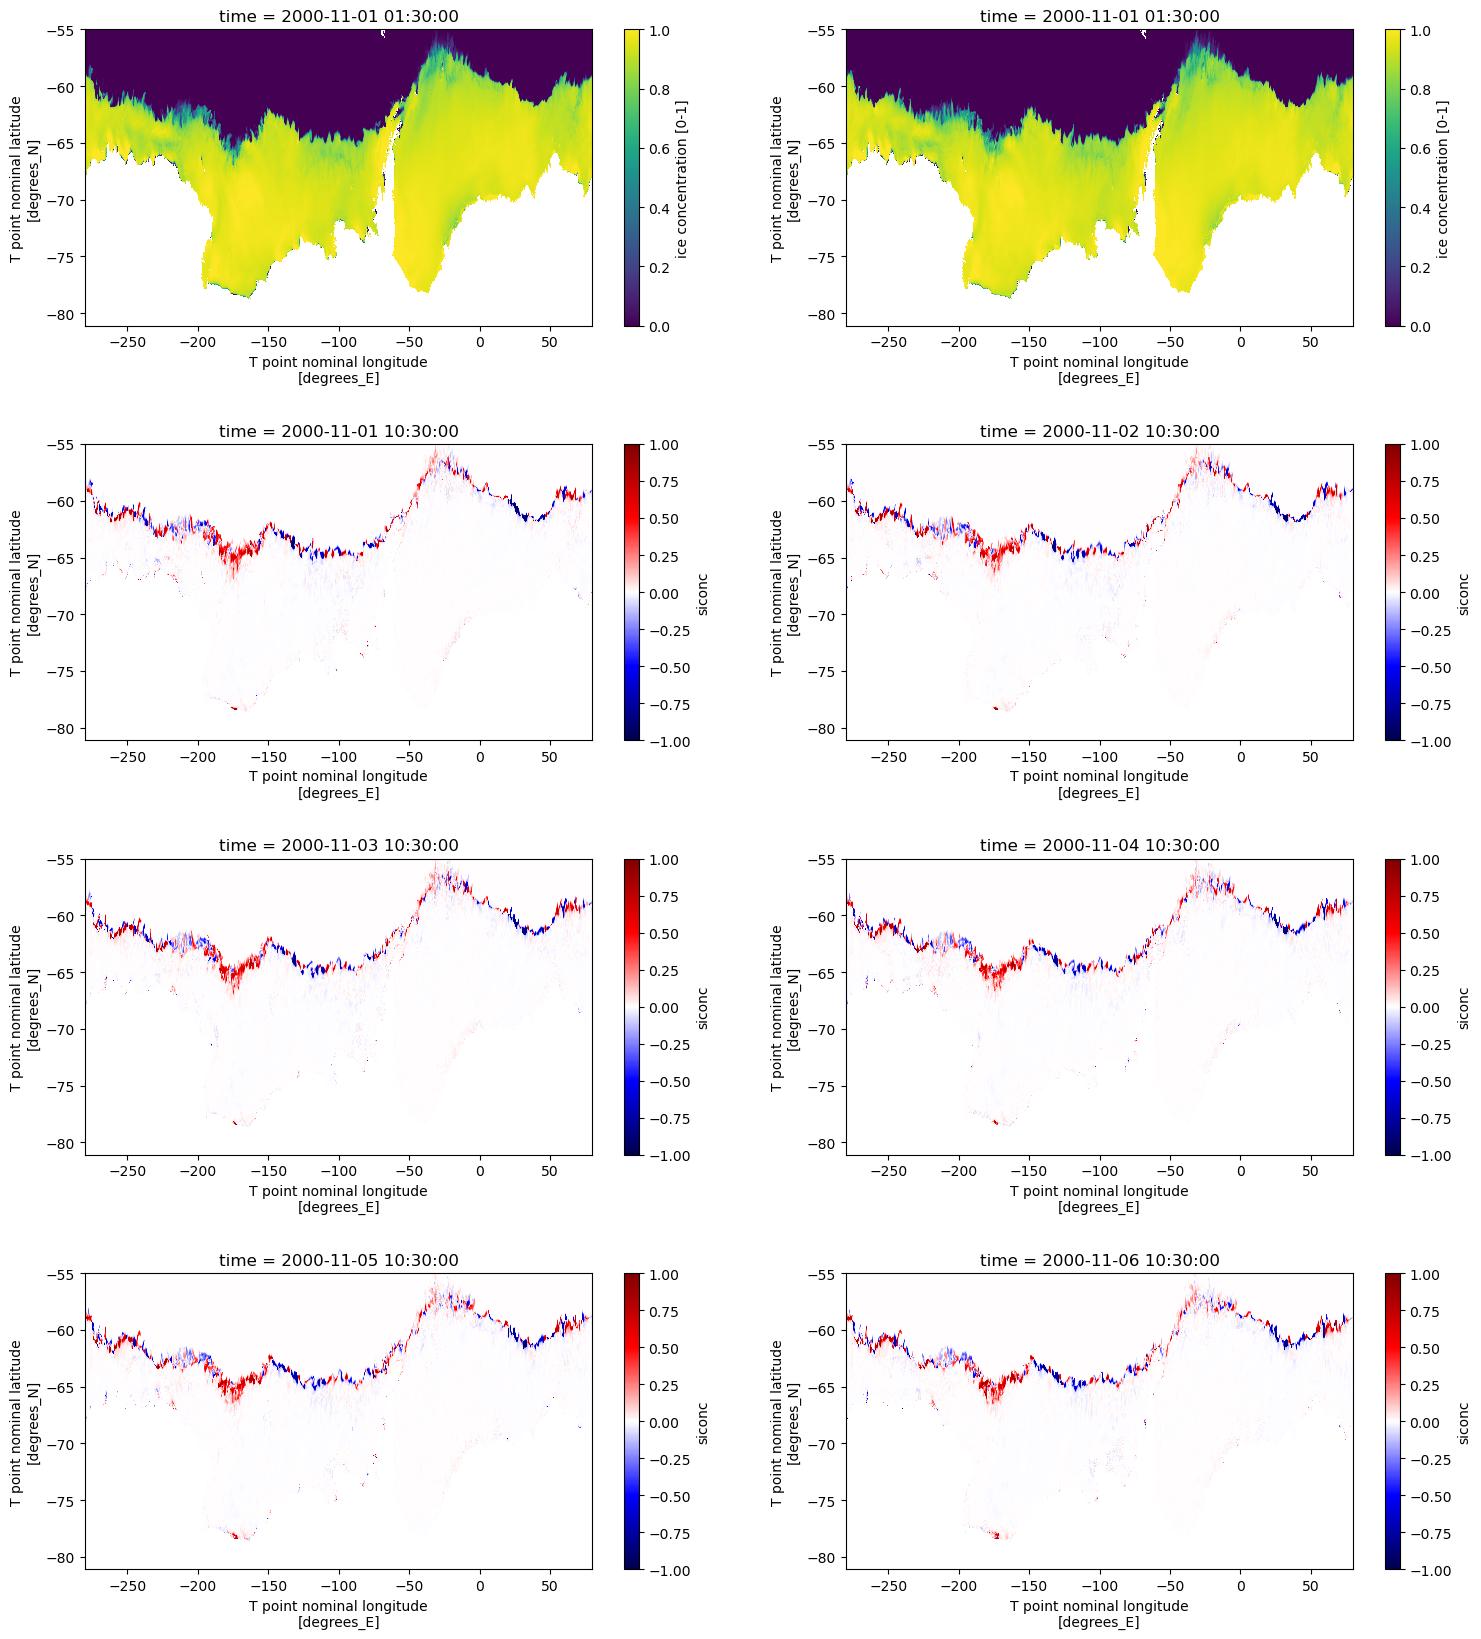

In [4]:
plt.figure(figsize=(18,20))
plt.subplots_adjust(hspace=0.4)

plt.subplot(4,2,1)
OLD0025_ice.siconc.isel(time=0).plot()
plt.subplot(4,2,2)
NEW0025_ice.siconc.isel(time=0).plot()

#differences
i=3
for k in range(3,48,8):
    plt.subplot(4,2,i)
    (NEW0025_ice.siconc.isel(time=k) - OLD0025_ice.siconc.isel(time=k)).plot(vmin=-1,vmax=1,cmap='seismic')
    i=i+1

Let's next try to do some stiching!


THe approach I will use is to average between runs, using a weight that changes from 1e3 to 1e-5 applied to theold run. that will allow us to a visually seamless stiching

In [5]:
#first importing the full old run
OLD0025_ice_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2}).sel(yT=lat_slice)


In [6]:
Ice_stiched = OLD0025_ice.siconc * np.nan
weights = np.logspace(2,0,len(OLD0025_ice.time)) - 1


for t in range(len(OLD0025_ice.time)):
    Ice_stiched[t,:,:] =  (( (OLD0025_ice.siconc.isel(time=t)*weights[t]) + (NEW0025_ice.siconc.isel(time=t)))/(weights[t]+1))

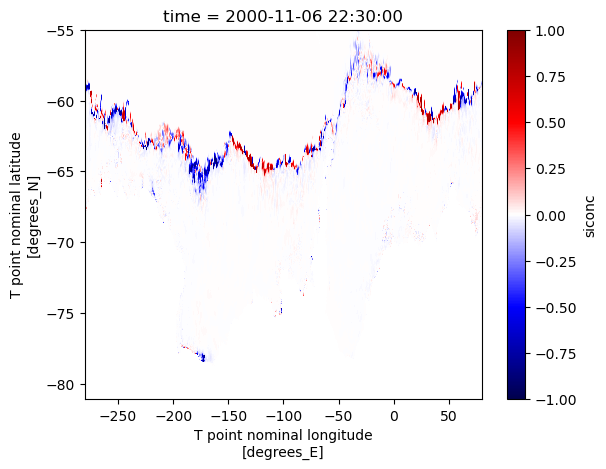

In [7]:
t=47
(OLD0025_ice.siconc.isel(time=t) - Ice_stiched.isel(time=t) ).plot(vmin=-1,vmax=1,cmap='seismic')

mergind new stiched data to old full data

In [8]:
%%time
#loading for substitution
OLD0025_ice_full.load()
Ice_stiched.load()
print('data loaded')

data loaded
CPU times: user 44.3 s, sys: 32.8 s, total: 1min 17s
Wall time: 1min 36s


In [9]:
ice0025_full_sitched = (OLD0025_ice_full.siconc * np.nan).copy()
ice0025_full_sitched[(80-48):,:,:] = Ice_stiched.values
ice0025_full_sitched[:48,:,:] = OLD0025_ice_full.siconc[:48,:,:].values

In [10]:
ice0025_full_sitched.load()
print('data loaded')

data loaded


In [11]:
#substituting now only the new data into the old one, without the stiching-smoothing method
ice0025_full_sharp = OLD0025_ice_full.copy()
ice0025_full_sharp['siconc'][(80-48):,:,:] = NEW0025_ice.siconc[:48,:,:].values
ice0025_full_sharp.load()
print('loaded new ice')

loaded new ice


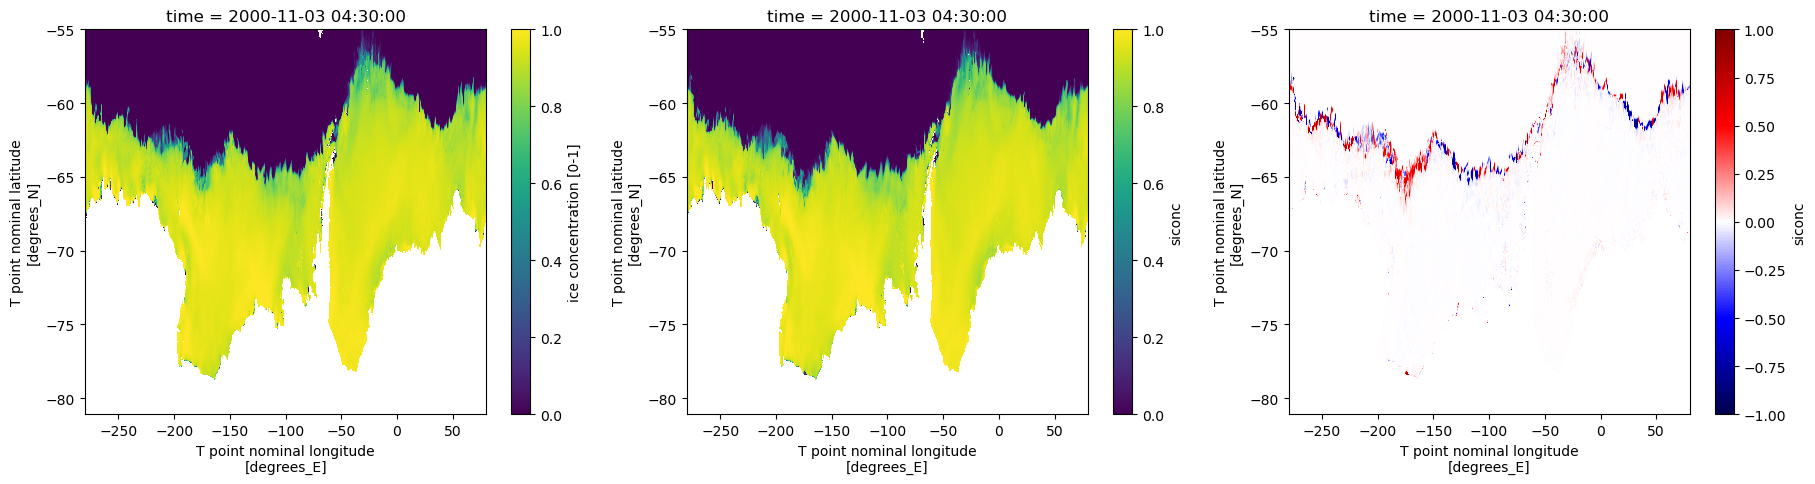

In [12]:
t=49
plt.figure(figsize=(22,5))
plt.subplots_adjust(hspace=0.4)
plt.subplot(1,3,1)
ice0025_full_sharp.siconc.isel(time=t).plot(vmin=0,vmax=1)
plt.subplot(1,3,2)
ice0025_full_sitched.isel(time=t).plot(vmin=0,vmax=1)
plt.subplot(1,3,3)
(ice0025_full_sharp.siconc.isel(time=t) - ice0025_full_sitched.isel(time=t)).plot(vmin=-1,vmax=1,cmap='seismic')

In [13]:
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_SIC/"

for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    plt.subplot(1,3,1)
    ice0025_full_sharp.siconc.isel(time=t).plot(vmin=0,vmax=1)
    plt.subplot(1,3,2)
    ice0025_full_sitched.isel(time=t).plot(vmin=0,vmax=1)
    plt.subplot(1,3,3)
    (ice0025_full_sharp.siconc.isel(time=t) - ice0025_full_sitched.isel(time=t)).plot(vmin=-1,vmax=1,cmap='seismic')
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'.png',dpi=300,bbox_inches='tight')
    plt.close()

In [15]:


frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie.mp4",   # use .avi for MPEG4
    frames,
    fps=10,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")

✅ Movie saved successfully (MPEG4 format)


## Saving stiched files

This process will use the whole netcdf, so It will suse a lot of memory. so we will wipe out the memory and start from scketch, and load each day at once

In [3]:
time_slice=slice('2000-11-01',None)
#Import all files again without cutting lat
OLD0025_ice = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2}).sel(time=time_slice)
NEW0025_ice = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2}).sel(time=time_slice)
#the full old run
OLD0025_ice_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2})

In [4]:
# recalculating the new ice, but without any latitude cut
Ice_stiched = OLD0025_ice.copy()
Ice_stiched['siconc'] = Ice_stiched['siconc'] * np.nan
weights = np.logspace(2,0,len(OLD0025_ice.time)) - 1

for t in range(len(OLD0025_ice.time)):
    Ice_stiched['siconc'][t,:,:] =  (( (OLD0025_ice.siconc.isel(time=t)*weights[t]) + (NEW0025_ice.siconc.isel(time=t)))/(weights[t]+1))

In [5]:
ice0025_full_sitched = OLD0025_ice_full.copy()
ice0025_full_sitched['siconc'][(80-48):,:,:] = Ice_stiched['siconc'].values
ice0025_full_sitched['siconc'][:48,:,:] = OLD0025_ice_full['siconc'][:48,:,:].values

In [3]:
stiched_dir = '/scratch/oz91/wf4500/panan_Hifreq_formovies_extension_sitched/output138_sitched/'

In [7]:
#setting the files directory for specifying file names
files = sorted(glob.glob('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc'))

In [10]:
%%time
#loop through 
for t in range(len(files)):
    data_orig = xr.open_dataset(files[t])
    time_target = data_orig.time[0].item().strftime('%Y-%m-%d')
    Ice_stiched_day =ice0025_full_sitched.sel(time=time_target)
    savedir = stiched_dir + files[t][85:]
    #saving file
    Ice_stiched_day.to_netcdf(savedir)
    print(time_target)


2000-10-28
2000-10-29
2000-10-30
2000-10-31
2000-11-01
2000-11-02
2000-11-03
2000-11-04
2000-11-05
2000-11-06
CPU times: user 4min 24s, sys: 3min 30s, total: 7min 54s
Wall time: 12min 40s


### Sanity check

In [13]:
#importing stictched and old data
OLD0025_ice_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2})
Newstiched0025_ice_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension_sitched/output138_sitched/*ice_daily_2000_3*.nc',chunks={'time': 1, 'yT': 1000, 'xT': 1000, 'nv': 2})